In [12]:
# ============================================================
# CELL 1 — INSTALL, IMPORT, LOAD, AND BUILD FACEBOOK BENCHMARK
# ============================================================

# ------------------------------------------------------------
# 0. Install required packages
# ------------------------------------------------------------

!pip uninstall -y community -q

!pip install -q \
    numpy \
    pandas \
    networkx \
    scikit-learn \
    tqdm \
    python-louvain \
    GraphRicciCurvature \
    scipy \
    igraph \
    leidenalg \
    jinja2


# ------------------------------------------------------------
# 1. Imports and configuration
# ------------------------------------------------------------

import random
import tarfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

import community_detection_utils as cdu


RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATASET_NAME = "Facebook"


# ------------------------------------------------------------
# 2. Data paths and URLs
# ------------------------------------------------------------

DATA_DIR = Path("./data/facebook")

DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

COMBINED_FILE = (
    DATA_DIR
    / "facebook_combined.txt.gz"
)

TAR_FILE = (
    DATA_DIR
    / "facebook.tar.gz"
)

EXTRACT_DIR = (
    DATA_DIR
    / "facebook"
)

COMBINED_URL = (
    "https://snap.stanford.edu/data/"
    "facebook_combined.txt.gz"
)

TAR_URL = (
    "https://snap.stanford.edu/data/"
    "facebook.tar.gz"
)


# ------------------------------------------------------------
# 3. Benchmark-selection settings
# ------------------------------------------------------------

MIN_CIRCLE_SIZE = 10
N_RANDOM_CIRCLES = 50


# ------------------------------------------------------------
# 4. Curvature settings
# ------------------------------------------------------------

LRC_ONLY_PCT = 10

LRC_COMBO_PCT = 2
ORC_COMBO_PCT = 2
# Connected-component selection settings
MIN_COMPONENT_NODES = 80
MAX_COMPONENT_NODES = 500

MIN_LABELS = 4
MAX_LABELS = 25
ALPHA = 0.5
ORC_ITERATIONS = 5

SEEDS = [
    0,
    1,
    2,
    3,
    4,
    42,
]


# ------------------------------------------------------------
# 5. Download and extract Facebook data
# ------------------------------------------------------------

cdu.download_if_missing(
    COMBINED_URL,
    COMBINED_FILE,
)

cdu.download_if_missing(
    TAR_URL,
    TAR_FILE,
)


if not EXTRACT_DIR.exists():

    print(
        "Extracting facebook.tar.gz..."
    )

    with tarfile.open(
        TAR_FILE,
        "r:gz",
    ) as tar:

        tar.extractall(
            DATA_DIR
        )

    print(
        "Extraction completed."
    )

else:

    print(
        "Facebook files already extracted."
    )


# ------------------------------------------------------------
# 6. Load Facebook graph and circles
# ------------------------------------------------------------

G_full = cdu.load_facebook_combined(
    COMBINED_FILE
)

communities = cdu.load_all_facebook_circles(
    EXTRACT_DIR,
    min_size=1,
)


print(
    G_full
)

print(
    "Total circles:",
    len(communities),
)

print(
    "Connected components:",
    nx.number_connected_components(
        G_full
    ),
)

print(
    "Largest component size:",
    len(
        max(
            nx.connected_components(
                G_full
            ),
            key=len,
        )
    ),
)

print(
    "\nCircle-size distribution:"
)

display(
    pd.Series(
        [
            community["size"]
            for community in communities
        ]
    ).describe()
)


# ------------------------------------------------------------
# 7. Compute structural metrics for eligible circles
# ------------------------------------------------------------

rows = []

for cid, community in tqdm(
    list(
        enumerate(
            communities
        )
    ),
    desc="Computing Facebook circle metrics",
):

    if (
        community["size"]
        < MIN_CIRCLE_SIZE
    ):
        continue

    metrics = (
        cdu.compute_community_metrics(
            G_full,
            community["nodes"],
        )
    )

    if metrics is not None:

        metrics[
            "community_id"
        ] = cid

        metrics[
            "ego_id"
        ] = community[
            "ego_id"
        ]

        metrics[
            "circle_name"
        ] = community[
            "circle_name"
        ]

        rows.append(
            metrics
        )


metric_df = pd.DataFrame(
    rows
)

metric_df = metric_df[
    np.isfinite(
        metric_df[
            "conductance"
        ]
    )
].copy()


print(
    "Eligible circles:",
    len(metric_df),
)

display(
    metric_df.describe()
)


# ------------------------------------------------------------
# 8. Reproducibly sample circles
# ------------------------------------------------------------

if len(metric_df) == 0:

    raise ValueError(
        "No eligible circles were found. "
        "Reduce MIN_CIRCLE_SIZE."
    )


rng = np.random.default_rng(
    RANDOM_SEED
)

number_to_select = min(
    N_RANDOM_CIRCLES,
    len(metric_df),
)

picked_ids = rng.choice(
    metric_df[
        "community_id"
    ].tolist(),
    size=number_to_select,
    replace=False,
).tolist()

picked_ids = sorted(
    picked_ids
)


selected_df = metric_df[
    metric_df[
        "community_id"
    ].isin(
        picked_ids
    )
].copy()


print(
    "Randomly selected circles:",
    len(selected_df),
)

display(
    selected_df[
        [
            "community_id",
            "ego_id",
            "circle_name",
            "size",
            "conductance",
            "BTD",
            "internal_edges",
            "boundary_edges",
        ]
    ]
)


# ------------------------------------------------------------
# 9. Build the raw benchmark graph
# ------------------------------------------------------------

node_to_cids = defaultdict(
    list
)

for cid in picked_ids:

    for node in communities[
        cid
    ][
        "nodes"
    ]:

        if node in G_full:

            node_to_cids[
                node
            ].append(
                cid
            )


nodes_of_interest = set(
    node_to_cids.keys()
)

G_raw = G_full.subgraph(
    nodes_of_interest
).copy()


print(
    f"Before GCC: "
    f"|V|={G_raw.number_of_nodes():,}, "
    f"|E|={G_raw.number_of_edges():,}"
)

print(
    "Components before GCC:",
    (
        nx.number_connected_components(
            G_raw
        )
        if G_raw.number_of_nodes() > 0
        else 0
    ),
)


# ------------------------------------------------------------
# ------------------------------------------------------------
# ------------------------------------------------------------
# 10. Retain the Giant Connected Component
# ------------------------------------------------------------

print(
    f"Before GCC: "
    f"|V|={G_raw.number_of_nodes():,}, "
    f"|E|={G_raw.number_of_edges():,}"
)

print(
    "Components before GCC:",
    (
        nx.number_connected_components(
            G_raw
        )
        if G_raw.number_of_nodes() > 0
        else 0
    ),
)


H = cdu.get_gcc(
    G_raw
)


print(
    f"After GCC: "
    f"|V|={H.number_of_nodes():,}, "
    f"|E|={H.number_of_edges():,}"
)

print(
    "Components after GCC:",
    (
        nx.number_connected_components(
            H
        )
        if H.number_of_nodes() > 0
        else 0
    ),
)
# ------------------------------------------------------------
# 11. Assign one ground-truth label to each node
# ------------------------------------------------------------

cid_to_label = {
    cid: label
    for label, cid in enumerate(
        picked_ids
    )
}

community_size = {
    cid: communities[
        cid
    ][
        "size"
    ]
    for cid in picked_ids
}


for node in H.nodes():

    node_cids = node_to_cids.get(
        node,
        [],
    )

    if len(node_cids) == 0:
        continue

    # For overlapping nodes, use the smallest selected circle.
    # This preserves the rule from the original notebook.

    best_cid = min(
        node_cids,
        key=lambda cid: community_size[
            cid
        ],
    )

    H.nodes[
        node
    ][
        "label_gt"
    ] = cid_to_label[
        best_cid
    ]

    H.nodes[
        node
    ][
        "original_cids"
    ] = node_cids

    H.nodes[
        node
    ][
        "is_overlap"
    ] = int(
        len(node_cids) > 1
    )


# ------------------------------------------------------------
# 12. Validate the final Facebook benchmark
# ------------------------------------------------------------

EVAL_NODES = [
    node
    for node in H.nodes()
    if "label_gt"
    in H.nodes[node]
]

labels = [
    H.nodes[
        node
    ][
        "label_gt"
    ]
    for node in EVAL_NODES
]


print(
    "Labeled nodes:",
    len(labels),
)

print(
    "Number of labels in GCC:",
    len(
        set(labels)
    ),
)

print(
    "Overlap fraction:",
    (
        np.mean(
            [
                H.nodes[
                    node
                ].get(
                    "is_overlap",
                    0,
                )
                for node in EVAL_NODES
            ]
        )
        if EVAL_NODES
        else np.nan
    ),
)


print(
    "\nGround-truth label sizes:"
)

display(
    pd.Series(
        labels
    )
    .value_counts()
    .sort_values(
        ascending=False
    )
)


component_sizes = sorted(
    [
        len(component)
        for component
        in nx.connected_components(
            H
        )
    ],
    reverse=True,
)


print(
    "\nComponent-size summary after GCC:"
)

display(
    pd.Series(
        component_sizes
    ).describe()
)


print(
    f"\nFinal Facebook benchmark: "
    f"|V|={H.number_of_nodes():,}, "
    f"|E|={H.number_of_edges():,}"
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Already exists: data/facebook/facebook_combined.txt.gz
Already exists: data/facebook/facebook.tar.gz
Facebook files already extracted.
Circle files: 10
Graph with 4039 nodes and 88234 edges
Total circles: 193
Connected components: 1
Largest component size: 4039

Circle-size distribution:


count    193.000000
mean      21.932642
std       42.682093
min        1.000000
25%        3.000000
50%        7.000000
75%       19.000000
max      308.000000
dtype: float64

Computing Facebook circle metrics: 100%|██████████| 193/193 [00:00<00:00, 442.47it/s]

Eligible circles: 84


,size,internal_edges,boundary_edges,boundary_triangles,internal_triangles,conductance,BTD,community_id,ego_id
count,84.000000,84.000000,84.000000,84.000000,8.400000e+01,84.000000,82.000000,84.000000,84.000000
mean,45.619048,716.119048,520.416667,21492.785714,4.549839e+04,0.494294,27.836121,90.666667,1107.988095
std,56.567031,2131.041441,695.534175,36125.735193,2.316242e+05,0.291312,23.692998,58.775729,956.220049
min,10.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.200000,0.000000,0.000000
25%,13.000000,31.000000,67.000000,1280.500000,3.172500e+02,0.217052,11.142458,37.750000,348.000000
50%,21.000000,71.500000,272.500000,4697.500000,1.708500e+03,0.489246,18.304409,83.500000,686.000000
75%,51.750000,303.250000,731.250000,23610.500000,6.068000e+03,0.730563,35.318285,142.750000,1912.000000
max,308.000000,15865.000000,4390.000000,210491.000000,2.019222e+06,1.000000,104.537983,183.000000,3980.000000


...

Before GCC: |V|=1,980, |E|=43,877
Components before GCC: 29
Before GCC: |V|=1,980, |E|=43,877
Components before GCC: 29
After GCC: |V|=1,771, |E|=42,220
Components after GCC: 1
Labeled nodes: 1771
Number of labels in GCC: 39
Overlap fraction: 0.14398644833427443

Ground-truth label sizes:


7     296
13    224
19    217
2     107
11     95
10     83
23     65
20     44
25     43
35     35
8      35
18     35
36     32
3      30
9      29
34     28
1      26
38     25
32     25
28     24
16     22
29     20
5      19
21     19
17     19
12     18
27     18
31     17
24     15
22     14
33     13
37     13
30     12
15     10
4      10
14     10
6      10
26      8
0       6
Name: count, dtype: int64


Component-size summary after GCC:


count       1.0
mean     1771.0
std         NaN
min      1771.0
25%      1771.0
50%      1771.0
75%      1771.0
max      1771.0
dtype: float64


Final Facebook benchmark: |V|=1,771, |E|=42,220


In [13]:
# ============================================================
# CELL 2 — PREPARE FACEBOOK LRC, ORC, AND COMBO GRAPHS
# ============================================================

print(
    f"Input Facebook benchmark: "
    f"|V|={H.number_of_nodes():,}, "
    f"|E|={H.number_of_edges():,}"
)


# ============================================================
# 1. PREPARE LRC-ONLY GRAPH
# ============================================================

lrc_info = cdu.prepare_lrc_graph(
    graph=H,
    lrc_pct=LRC_ONLY_PCT,
    print_distribution=True,
)

G_lrc = lrc_info["graph"]

print("\n" + "=" * 65)
print("LRC-only graph prepared")
print("=" * 65)

print(
    f"Output graph: "
    f"|V|={G_lrc.number_of_nodes():,}, "
    f"|E|={G_lrc.number_of_edges():,}"
)

print(
    "Removed LRC edges:",
    lrc_info["removed_lrc"],
)

print(
    "LRC cutoff:",
    lrc_info["cutoff_lrc"],
)

print(
    "Preparation time:",
    f"{lrc_info['prep_time']:.2f} seconds",
)


# ============================================================
# 2. PREPARE ORC-ONLY GRAPH
# ============================================================

orc_info = cdu.prepare_orc_graph(
    graph=H,
    alpha=ALPHA,
    iterations=ORC_ITERATIONS,
    method="Sinkhorn",
)

G_orc = orc_info["graph"]

print("\n" + "=" * 65)
print("ORC-only graph prepared")
print("=" * 65)

print(
    f"Output graph: "
    f"|V|={G_orc.number_of_nodes():,}, "
    f"|E|={G_orc.number_of_edges():,}"
)

print(
    "Alpha:",
    orc_info["alpha"],
)

print(
    "Ricci-flow iterations:",
    orc_info["iterations"],
)

print(
    "Preparation time:",
    f"{orc_info['prep_time']:.2f} seconds",
)


# ============================================================
# 3. PREPARE LRC → ORC COMBO GRAPH
# ============================================================

combo_info = cdu.prepare_combo_graph(
    graph=H,
    lrc_pct=LRC_COMBO_PCT,
    orc_pct=ORC_COMBO_PCT,
    alpha=ALPHA,
    iterations=ORC_ITERATIONS,
    method="Sinkhorn",
)

G_combo = combo_info["graph"]

print("\n" + "=" * 65)
print("LRC → ORC combo graph prepared")
print("=" * 65)

print(
    f"Output graph: "
    f"|V|={G_combo.number_of_nodes():,}, "
    f"|E|={G_combo.number_of_edges():,}"
)

print(
    "Removed during LRC pruning:",
    combo_info["removed_lrc"],
)

print(
    "Removed during ORC pruning:",
    combo_info["removed_orc"],
)

print(
    "LRC cutoff:",
    combo_info["cutoff_lrc"],
)

print(
    "ORC cutoff:",
    combo_info["cutoff_orc"],
)

print(
    "Preparation time:",
    f"{combo_info['prep_time']:.2f} seconds",
)


# ============================================================
# 4. GRAPH-REDUCTION SUMMARY
# ============================================================

input_nodes = H.number_of_nodes()
input_edges = H.number_of_edges()

prepared_graph_summary = pd.DataFrame(
    [
        {
            "Method": "LRC-only",
            "Input Nodes": input_nodes,
            "Input Edges": input_edges,
            "Output Nodes": G_lrc.number_of_nodes(),
            "Output Edges": G_lrc.number_of_edges(),
            "Node Reduction (%)": (
                100
                * (
                    1
                    - G_lrc.number_of_nodes()
                    / input_nodes
                )
            ),
            "Edge Reduction (%)": (
                100
                * (
                    1
                    - G_lrc.number_of_edges()
                    / input_edges
                )
            ),
            "Preparation Time (s)": (
                lrc_info["prep_time"]
            ),
        },
        {
            "Method": "ORC-only",
            "Input Nodes": input_nodes,
            "Input Edges": input_edges,
            "Output Nodes": G_orc.number_of_nodes(),
            "Output Edges": G_orc.number_of_edges(),
            "Node Reduction (%)": (
                100
                * (
                    1
                    - G_orc.number_of_nodes()
                    / input_nodes
                )
            ),
            "Edge Reduction (%)": (
                100
                * (
                    1
                    - G_orc.number_of_edges()
                    / input_edges
                )
            ),
            "Preparation Time (s)": (
                orc_info["prep_time"]
            ),
        },
        {
            "Method": "LRC→ORC combo",
            "Input Nodes": input_nodes,
            "Input Edges": input_edges,
            "Output Nodes": G_combo.number_of_nodes(),
            "Output Edges": G_combo.number_of_edges(),
            "Node Reduction (%)": (
                100
                * (
                    1
                    - G_combo.number_of_nodes()
                    / input_nodes
                )
            ),
            "Edge Reduction (%)": (
                100
                * (
                    1
                    - G_combo.number_of_edges()
                    / input_edges
                )
            ),
            "Preparation Time (s)": (
                combo_info["prep_time"]
            ),
        },
    ]
)

prepared_graph_summary[
    [
        "Node Reduction (%)",
        "Edge Reduction (%)",
        "Preparation Time (s)",
    ]
] = prepared_graph_summary[
    [
        "Node Reduction (%)",
        "Edge Reduction (%)",
        "Preparation Time (s)",
    ]
].round(2)

print("\nPrepared Facebook graph summary:")

display(prepared_graph_summary)


# ============================================================
# 5. VALIDATION CHECKS
# ============================================================

assert H.number_of_nodes() > 0
assert H.number_of_edges() > 0

assert G_lrc.number_of_nodes() > 0
assert G_lrc.number_of_edges() > 0

assert G_orc.number_of_nodes() > 0
assert G_orc.number_of_edges() > 0

assert G_combo.number_of_nodes() > 0
assert G_combo.number_of_edges() > 0

# Multiple connected components are allowed after pruning.
# All components are intentionally retained.
assert set(G_lrc.nodes()) == set(H.nodes())
assert set(G_orc.nodes()) == set(H.nodes())
assert set(G_combo.nodes()) == set(H.nodes())

print(
    "\nAll prepared Facebook graphs are non-empty, "
    "and all input nodes/components are retained."
)

print("LRC components:", nx.number_connected_components(G_lrc))
print("ORC components:", nx.number_connected_components(G_orc))
print("Combo components:", nx.number_connected_components(G_combo))

Input Facebook benchmark: |V|=1,771, |E|=42,220
LRC distribution:
count    42220.000000
mean        -0.153163
std          0.569021
min         -1.953388
25%         -0.565620
50%         -0.137248
75%          0.318408
max          1.500000
dtype: float64

LRC-only graph prepared
Output graph: |V|=1,104, |E|=17,954
Removed LRC edges: 4222
LRC cutoff: -0.9100579975579974
Preparation time: 0.62 seconds

ORC-only graph prepared
Output graph: |V|=1,771, |E|=42,220
Alpha: 0.5
Ricci-flow iterations: 5
Preparation time: 79.05 seconds

LRC → ORC combo graph prepared
Output graph: |V|=1,708, |E|=40,312
Removed during LRC pruning: 845
Removed during ORC pruning: 826
LRC cutoff: -1.3630407523510972
ORC cutoff: -0.08917159247518291
Preparation time: 81.60 seconds

Prepared Facebook graph summary:


,Method,Input Nodes,Input Edges,Output Nodes,Output Edges,Node Reduction (%),Edge Reduction (%),Preparation Time (s)
0,LRC-only,1771,42220,1104,17954,37.66,57.48,0.62
1,ORC-only,1771,42220,1771,42220,0.00,0.00,79.05
2,LRC→ORC combo,1771,42220,1708,40312,3.56,4.52,81.60



All prepared Facebook graphs are non-empty and connected.


In [14]:
# ============================================================
# CELL 3 — FACEBOOK MULTI-SEED EVALUATION AND RESULT TABLES
# ============================================================

prepared = [
    lrc_info,
    orc_info,
    combo_info,
]


# ============================================================
# 1. SINGLE-SEED RESULTS (SEED = 42)
# ============================================================

single_seed_rows = []

single_seed_rows.append(
    cdu.evaluate_plain_graph(
        graph=H,
        algorithm="louvain",
        seed=RANDOM_SEED,
    )
)

single_seed_rows.append(
    cdu.evaluate_plain_graph(
        graph=H,
        algorithm="leiden",
        seed=RANDOM_SEED,
    )
)

for info in prepared:

    single_seed_rows.append(
        cdu.evaluate_prepared_graph(
            info=info,
            algorithm="louvain",
            seed=RANDOM_SEED,
        )
    )

    single_seed_rows.append(
        cdu.evaluate_prepared_graph(
            info=info,
            algorithm="leiden",
            seed=RANDOM_SEED,
        )
    )


df_single_seed = pd.DataFrame(
    single_seed_rows
)

print(
    f"Facebook single-seed results "
    f"(seed={RANDOM_SEED}):"
)

display(
    df_single_seed[
        [
            "method",
            "algorithm",
            "seed",
            "ARI",
            "NMI",
            "n_eval",
            "V",
            "E",
            "runtime_sec",
            "prep_time",
            "community_time",
            "removed_lrc",
            "removed_orc",
        ]
    ].sort_values(
        "ARI",
        ascending=False,
    )
)

df_single_seed.to_csv(
    "facebook_single_seed_results.csv",
    index=False,
)


# ============================================================
# 2. MULTI-SEED EVALUATION
# ============================================================

multi_rows = []

for seed in SEEDS:

    print("\n" + "=" * 70)
    print("Seed:", seed)
    print("=" * 70)

    # Plain Louvain
    plain_louvain = cdu.evaluate_plain_graph(
        graph=H,
        algorithm="louvain",
        seed=seed,
    )

    multi_rows.append(
        plain_louvain
    )

    print(
        f"{plain_louvain['method']}: "
        f"ARI={plain_louvain['ARI']:.4f}, "
        f"NMI={plain_louvain['NMI']:.4f}, "
        f"Runtime={plain_louvain['runtime_sec']:.2f}s"
    )

    # Plain Leiden
    plain_leiden = cdu.evaluate_plain_graph(
        graph=H,
        algorithm="leiden",
        seed=seed,
    )

    multi_rows.append(
        plain_leiden
    )

    print(
        f"{plain_leiden['method']}: "
        f"ARI={plain_leiden['ARI']:.4f}, "
        f"NMI={plain_leiden['NMI']:.4f}, "
        f"Runtime={plain_leiden['runtime_sec']:.2f}s"
    )

    # Curvature methods with Louvain
    for info in prepared:

        result = cdu.evaluate_prepared_graph(
            info=info,
            algorithm="louvain",
            seed=seed,
        )

        multi_rows.append(
            result
        )

        print(
            f"{result['method']}: "
            f"ARI={result['ARI']:.4f}, "
            f"NMI={result['NMI']:.4f}, "
            f"Runtime={result['runtime_sec']:.2f}s"
        )

    # Curvature methods with Leiden
    for info in prepared:

        result = cdu.evaluate_prepared_graph(
            info=info,
            algorithm="leiden",
            seed=seed,
        )

        multi_rows.append(
            result
        )

        print(
            f"{result['method']}: "
            f"ARI={result['ARI']:.4f}, "
            f"NMI={result['NMI']:.4f}, "
            f"Runtime={result['runtime_sec']:.2f}s"
        )


# ============================================================
# 3. COMPLETE MULTI-SEED DATAFRAME
# ============================================================

df_multi = pd.DataFrame(
    multi_rows
)

expected_rows = len(SEEDS) * 8

print(
    "\nMulti-seed dataframe shape:",
    df_multi.shape,
)

assert len(df_multi) == expected_rows, (
    f"Expected {expected_rows} rows, "
    f"but found {len(df_multi)}."
)

display(
    df_multi[
        [
            "method",
            "algorithm",
            "seed",
            "ARI",
            "NMI",
            "n_eval",
            "V",
            "E",
            "runtime_sec",
            "prep_time",
            "community_time",
            "removed_lrc",
            "removed_orc",
        ]
    ].sort_values(
        [
            "seed",
            "method",
        ]
    )
)

df_multi.to_csv(
    "facebook_multiseed_results.csv",
    index=False,
)


# ============================================================
# 4. NUMERIC SUMMARY
# ============================================================

numeric_summary = (
    df_multi
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        ARI_mean=(
            "ARI",
            "mean",
        ),
        ARI_std=(
            "ARI",
            "std",
        ),
        NMI_mean=(
            "NMI",
            "mean",
        ),
        NMI_std=(
            "NMI",
            "std",
        ),
        Runtime_mean=(
            "runtime_sec",
            "mean",
        ),
        Runtime_std=(
            "runtime_sec",
            "std",
        ),
        n_eval_mean=(
            "n_eval",
            "mean",
        ),
        Output_Nodes=(
            "V",
            "mean",
        ),
        Output_Edges=(
            "E",
            "mean",
        ),
        Prep_Time_mean=(
            "prep_time",
            "mean",
        ),
        Community_Time_mean=(
            "community_time",
            "mean",
        ),
    )
    .sort_values(
        "ARI_mean",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nFacebook numeric summary:"
)

display(
    numeric_summary
)

numeric_summary.to_csv(
    "facebook_numeric_summary.csv",
    index=False,
)


# ============================================================
# 5. PAPER-STYLE MEAN ± STD TABLE
# ============================================================

paper_table = numeric_summary.copy()

paper_table["ARI"] = (
    paper_table["ARI_mean"].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + paper_table["ARI_std"].map(
        lambda value: f"{value:.3f}"
    )
)

paper_table["NMI"] = (
    paper_table["NMI_mean"].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + paper_table["NMI_std"].map(
        lambda value: f"{value:.3f}"
    )
)

paper_table["Runtime (s)"] = (
    paper_table["Runtime_mean"].map(
        lambda value: f"{value:.2f}"
    )
    + " ± "
    + paper_table["Runtime_std"].map(
        lambda value: f"{value:.2f}"
    )
)

paper_table["Input Nodes"] = (
    H.number_of_nodes()
)

paper_table["Input Edges"] = (
    H.number_of_edges()
)

paper_table["Output Nodes"] = (
    paper_table[
        "Output_Nodes"
    ].round().astype(int)
)

paper_table["Output Edges"] = (
    paper_table[
        "Output_Edges"
    ].round().astype(int)
)

paper_table["Edge Reduction (%)"] = (
    100
    * (
        1
        - paper_table["Output Edges"]
        / H.number_of_edges()
    )
).round(2)

paper_table = paper_table[
    [
        "method",
        "ARI",
        "NMI",
        "Runtime (s)",
        "Input Nodes",
        "Input Edges",
        "Output Nodes",
        "Output Edges",
        "Edge Reduction (%)",
    ]
].rename(
    columns={
        "method": "Method",
    }
)

print(
    "\nFacebook paper-style table:"
)

display(
    paper_table
)

paper_table.to_csv(
    "facebook_final_mean_std_table.csv",
    index=False,
)


# ============================================================
# 6. THREE-METHOD MAIN PAPER TABLE
# ============================================================

main_methods = [
    "LRC-only",
    "ORC-only",
    "LRC→ORC combo",
]

main_paper_table = (
    paper_table[
        paper_table[
            "Method"
        ].isin(
            main_methods
        )
    ]
    .copy()
)

main_paper_table["Method"] = pd.Categorical(
    main_paper_table["Method"],
    categories=main_methods,
    ordered=True,
)

main_paper_table = (
    main_paper_table
    .sort_values(
        "Method"
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nThree-method Facebook table "
    "for the main article:"
)

display(
    main_paper_table
)

main_paper_table.to_csv(
    "facebook_main_three_method_table.csv",
    index=False,
)


# ============================================================
# 7. PAIRED STATISTICAL TESTS
# ============================================================

ari_tests_vs_orc = cdu.paired_tests(
    results=df_multi,
    baseline_method="ORC-only",
    metric="ARI",
)

nmi_tests_vs_orc = cdu.paired_tests(
    results=df_multi,
    baseline_method="ORC-only",
    metric="NMI",
)

print(
    "\nPaired ARI tests against ORC-only:"
)

display(
    ari_tests_vs_orc
)

print(
    "\nPaired NMI tests against ORC-only:"
)

display(
    nmi_tests_vs_orc
)

ari_tests_vs_orc.to_csv(
    "facebook_ari_paired_tests_vs_orc.csv",
    index=False,
)

nmi_tests_vs_orc.to_csv(
    "facebook_nmi_paired_tests_vs_orc.csv",
    index=False,
)


# ============================================================
# 8. LATEX EXPORT
# ============================================================

latex_table = main_paper_table.to_latex(
    index=False,
    escape=False,
    caption=(
        "Community detection results on the Facebook "
        "benchmark, reported as mean "
        "$\\pm$ standard deviation across random seeds."
    ),
    label="tab:facebook_results",
)

print(
    "\nFacebook LaTeX table:"
)

print(
    latex_table
)

with open(
    "facebook_main_three_method_table.tex",
    "w",
    encoding="utf-8",
) as file:

    file.write(
        latex_table
    )

Facebook single-seed results (seed=42):


,method,algorithm,seed,ARI,NMI,n_eval,V,E,runtime_sec,prep_time,community_time,removed_lrc,removed_orc
1,Plain Leiden,leiden,42,0.684270,0.784495,1771,1771,42220,0.183415,0.000000,0.183415,0,0
0,Plain Louvain,louvain,42,0.639451,0.769366,1771,1771,42220,0.325439,0.000000,0.325439,0,0
7,LRC→ORC combo + Leiden,leiden,42,0.583652,0.720280,1708,1708,40312,81.781486,81.599807,0.181680,845,826
4,ORC-only,louvain,42,0.583543,0.735669,1771,1771,42220,79.519916,79.048241,0.471675,0,0
6,LRC→ORC combo,louvain,42,0.583419,0.721236,1708,1708,40312,81.926845,81.599807,0.327038,845,826
5,ORC-only + Leiden,leiden,42,0.582106,0.733441,1771,1771,42220,79.242538,79.048241,0.194297,0,0
3,LRC-only + Leiden,leiden,42,0.539966,0.706102,1104,1104,17954,0.713863,0.623943,0.089921,4222,0
2,LRC-only,louvain,42,0.499195,0.705793,1104,1104,17954,0.790156,0.623943,0.166213,4222,0



Seed: 0
Plain Louvain: ARI=0.6316, NMI=0.7692, Runtime=0.30s
Plain Leiden: ARI=0.6280, NMI=0.7687, Runtime=0.19s
LRC-only: ARI=0.5107, NMI=0.6966, Runtime=0.79s
ORC-only: ARI=0.5841, NMI=0.7358, Runtime=79.45s
LRC→ORC combo: ARI=0.5837, NMI=0.7203, Runtime=81.98s
LRC-only + Leiden: ARI=0.5570, NMI=0.7133, Runtime=0.71s
ORC-only + Leiden: ARI=0.5836, NMI=0.7345, Runtime=79.24s
LRC→ORC combo + Leiden: ARI=0.5839, NMI=0.7207, Runtime=81.78s

Seed: 1
Plain Louvain: ARI=0.6857, NMI=0.7816, Runtime=0.35s
Plain Leiden: ARI=0.6189, NMI=0.7653, Runtime=0.18s
LRC-only: ARI=0.5503, NMI=0.7026, Runtime=0.77s
ORC-only: ARI=0.5841, NMI=0.7358, Runtime=79.49s
LRC→ORC combo: ARI=0.5836, NMI=0.7205, Runtime=81.93s
LRC-only + Leiden: ARI=0.5151, NMI=0.7057, Runtime=0.71s
ORC-only + Leiden: ARI=0.5845, NMI=0.7346, Runtime=79.40s
LRC→ORC combo + Leiden: ARI=0.5890, NMI=0.7241, Runtime=81.79s

Seed: 2
Plain Louvain: ARI=0.6441, NMI=0.7711, Runtime=0.40s
Plain Leiden: ARI=0.6260, NMI=0.7678, Runtime=0.18s


,method,algorithm,seed,ARI,NMI,n_eval,V,E,runtime_sec,prep_time,community_time,removed_lrc,removed_orc
2,LRC-only,louvain,0,0.510719,0.696632,1104,1104,17954,0.791245,0.623943,0.167302,4222,0
5,LRC-only + Leiden,leiden,0,0.556991,0.713342,1104,1104,17954,0.713756,0.623943,0.089814,4222,0
4,LRC→ORC combo,louvain,0,0.583652,0.720280,1708,1708,40312,81.980437,81.599807,0.380630,845,826
7,LRC→ORC combo + Leiden,leiden,0,0.583938,0.720657,1708,1708,40312,81.782973,81.599807,0.183166,845,826
3,ORC-only,louvain,0,0.584076,0.735777,1771,1771,42220,79.446335,79.048241,0.398094,0,0
6,ORC-only + Leiden,leiden,0,0.583618,0.734514,1771,1771,42220,79.241798,79.048241,0.193557,0,0
1,Plain Leiden,leiden,0,0.627978,0.768723,1771,1771,42220,0.187620,0.000000,0.187620,0,0
0,Plain Louvain,louvain,0,0.631573,0.769244,1771,1771,42220,0.300547,0.000000,0.300547,0,0
10,LRC-only,louvain,1,0.550342,0.702628,1104,1104,17954,0.771824,0.623943,0.147881,4222,0
13,LRC-only + Leiden,leiden,1,0.515079,0.705723,1104,1104,17954,0.710552,0.623943,0.086610,4222,0



Facebook numeric summary:


...


Paired ARI tests against ORC-only:


,baseline,method,metric,n_pairs,baseline_mean,method_mean,mean_diff,paired_t_p,wilcoxon_p
0,ORC-only,LRC-only,ARI,6,0.582548,0.525306,-0.057242,0.001587,0.03125
1,ORC-only,LRC-only + Leiden,ARI,6,0.582548,0.539865,-0.042683,0.001175,0.03125
2,ORC-only,LRC→ORC combo,ARI,6,0.582548,0.583079,0.000531,0.571194,1.00000
3,ORC-only,LRC→ORC combo + Leiden,ARI,6,0.582548,0.585800,0.003252,0.109970,0.09375
4,ORC-only,ORC-only + Leiden,ARI,6,0.582548,0.582731,0.000182,0.862679,0.84375
5,ORC-only,Plain Leiden,ARI,6,0.582548,0.634868,0.052320,0.003134,0.03125
6,ORC-only,Plain Louvain,ARI,6,0.582548,0.646226,0.063677,0.000528,0.03125



Paired NMI tests against ORC-only:


,baseline,method,metric,n_pairs,baseline_mean,method_mean,mean_diff,paired_t_p,wilcoxon_p
0,ORC-only,LRC-only,NMI,6,0.735216,0.705983,-0.029233,8.382764e-05,0.03125
1,ORC-only,LRC-only + Leiden,NMI,6,0.735216,0.705923,-0.029293,9.910890e-05,0.03125
2,ORC-only,LRC→ORC combo,NMI,6,0.735216,0.720686,-0.014531,2.887479e-07,0.03125
3,ORC-only,LRC→ORC combo + Leiden,NMI,6,0.735216,0.721784,-0.013433,1.397623e-05,0.03125
4,ORC-only,ORC-only + Leiden,NMI,6,0.735216,0.733763,-0.001453,1.058011e-02,0.03125
5,ORC-only,Plain Leiden,NMI,6,0.735216,0.770476,0.035260,5.511030e-05,0.03125
6,ORC-only,Plain Louvain,NMI,6,0.735216,0.771685,0.036469,8.134495e-06,0.03125



Facebook LaTeX table:
\begin{table}
\caption{Community detection results on the Facebook benchmark, reported as mean $\pm$ standard deviation across random seeds.}
\label{tab:facebook_results}
\begin{tabular}{llllrrrrr}
\toprule
Method & ARI & NMI & Runtime (s) & Input Nodes & Input Edges & Output Nodes & Output Edges & Edge Reduction (%) \\
\midrule
LRC-only & 0.525 ± 0.023 & 0.706 ± 0.006 & 0.79 ± 0.01 & 1771 & 42220 & 1104 & 17954 & 57.480000 \\
ORC-only & 0.583 ± 0.002 & 0.735 ± 0.001 & 79.48 ± 0.03 & 1771 & 42220 & 1771 & 42220 & 0.000000 \\
LRC→ORC combo & 0.583 ± 0.001 & 0.721 ± 0.001 & 81.96 ± 0.03 & 1771 & 42220 & 1708 & 40312 & 4.520000 \\
\bottomrule
\end{tabular}
\end{table}



In [15]:
# ============================================================
# CELL 4 — STRUCTURAL ANALYSIS OF THE FACEBOOK BENCHMARK
# ============================================================

# ============================================================
# 1. BASIC GRAPH STATISTICS
# ============================================================

basic_stats = pd.DataFrame(
    [
        cdu.basic_graph_stats(
            graph=H,
            dataset_name="Facebook",
            include_path_metrics=True,
        )
    ]
)

print("Basic Facebook graph statistics:")

display(basic_stats)

basic_stats.to_csv(
    "facebook_basic_graph_stats.csv",
    index=False,
)


# ============================================================
# 2. GROUND-TRUTH LABEL STATISTICS
# ============================================================

label_stats_dict, label_counts = (
    cdu.label_structure_stats(
        graph=H,
        label_attribute="label_gt",
        overlap_attribute="is_overlap",
    )
)

label_stats = pd.DataFrame(
    [label_stats_dict]
)

print("\nGround-truth label statistics:")

display(label_stats)

print("\nGround-truth label sizes:")

label_size_table = (
    label_counts
    .sort_values(
        ascending=False
    )
    .rename(
        "Community Size"
    )
    .to_frame()
)

display(label_size_table)

label_stats.to_csv(
    "facebook_label_structure_stats.csv",
    index=False,
)

label_size_table.to_csv(
    "facebook_label_sizes.csv",
)


# ============================================================
# 3. STRUCTURAL METRICS FOR EACH GROUND-TRUTH LABEL
# ============================================================

unique_labels = sorted(
    {
        H.nodes[node]["label_gt"]
        for node in H.nodes()
        if "label_gt" in H.nodes[node]
    }
)

label_metric_rows = []

for label in unique_labels:

    metrics = cdu.compute_label_metrics(
        graph=H,
        label=label,
        label_attribute="label_gt",
    )

    if metrics is not None:
        label_metric_rows.append(
            metrics
        )


label_metric_df = pd.DataFrame(
    label_metric_rows
)

print("\nPer-label structural metrics:")

display(
    label_metric_df
    .sort_values(
        "label"
    )
    .reset_index(
        drop=True
    )
)

label_metric_df.to_csv(
    "facebook_per_label_structural_metrics.csv",
    index=False,
)


# ============================================================
# 4. MEAN AND WEIGHTED STRUCTURAL MEASURES
# ============================================================

mean_conductance = (
    label_metric_df[
        "conductance"
    ].mean()
)

weighted_conductance = (
    cdu.weighted_mean(
        dataframe=label_metric_df,
        value_col="conductance",
        weight_col="size",
    )
)

mean_btd = (
    label_metric_df[
        "BTD"
    ].mean()
)

weighted_btd = (
    cdu.weighted_mean(
        dataframe=label_metric_df,
        value_col="BTD",
        weight_col="size",
    )
)

mean_internal_density = (
    label_metric_df[
        "internal_density"
    ].mean()
)

weighted_internal_density = (
    cdu.weighted_mean(
        dataframe=label_metric_df,
        value_col="internal_density",
        weight_col="size",
    )
)


structural_summary = pd.DataFrame(
    [
        {
            "Dataset": "Facebook",
            "Nodes": H.number_of_nodes(),
            "Edges": H.number_of_edges(),
            "Ground-truth Labels": len(unique_labels),
            "Mean Conductance": mean_conductance,
            "Weighted Conductance": weighted_conductance,
            "Mean BTD": mean_btd,
            "Weighted BTD": weighted_btd,
            "Mean Internal Density": mean_internal_density,
            "Weighted Internal Density": (
                weighted_internal_density
            ),
            "Overlap Fraction": (
                label_stats_dict[
                    "overlap_fraction"
                ]
            ),
        }
    ]
)

numeric_columns = (
    structural_summary
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

structural_summary[
    numeric_columns
] = structural_summary[
    numeric_columns
].round(4)


print("\nFacebook structural summary:")

display(structural_summary)

structural_summary.to_csv(
    "facebook_structural_summary.csv",
    index=False,
)


# ============================================================
# 5. GROUND-TRUTH MODULARITY
# ============================================================

gt_partition = cdu.ground_truth_partition(
    graph=H,
    label_attribute="label_gt",
)

if len(gt_partition) > 1:

    gt_modularity = (
        nx.algorithms.community.modularity(
            H,
            gt_partition,
            weight=None,
        )
    )

else:

    gt_modularity = np.nan


print(
    "\nGround-truth modularity:",
    gt_modularity,
)


# ============================================================
# 6. GRAPH-LEVEL OVERLAP CHECK
# ============================================================

overlap_nodes = [
    node
    for node in H.nodes()
    if H.nodes[node].get(
        "is_overlap",
        0,
    ) == 1
]

overlap_fraction_direct = (
    len(overlap_nodes)
    / H.number_of_nodes()
    if H.number_of_nodes() > 0
    else np.nan
)

print(
    "Number of overlapping nodes:",
    len(overlap_nodes),
)

print(
    "Direct overlap fraction:",
    overlap_fraction_direct,
)


# ============================================================
# 7. IDENTIFY THE BEST METHOD FROM THE EXPERIMENTAL RESULTS
# ============================================================

best_result = (
    numeric_summary
    .sort_values(
        "ARI_mean",
        ascending=False,
    )
    .iloc[0]
)

best_method = best_result[
    "method"
]

best_ari = best_result[
    "ARI_mean"
]

best_nmi = best_result[
    "NMI_mean"
]


print(
    "\nBest method by mean ARI:",
    best_method,
)

print(
    "Best mean ARI:",
    best_ari,
)

print(
    "Corresponding mean NMI:",
    best_nmi,
)


# ============================================================
# 8. FINAL STRUCTURAL-REGIME ROW
# ============================================================

structural_regime_row = pd.DataFrame(
    [
        {
            "Dataset": "Facebook",
            "Nodes": H.number_of_nodes(),
            "Edges": H.number_of_edges(),
            "Labels": len(unique_labels),
            "Conductance": mean_conductance,
            "Weighted Conductance": weighted_conductance,
            "BTD": mean_btd,
            "Weighted BTD": weighted_btd,
            "Ground-truth Modularity": gt_modularity,
            "Overlap Fraction": overlap_fraction_direct,
            "Best Method": best_method,
            "Best ARI": best_ari,
            "Best NMI": best_nmi,
        }
    ]
)

numeric_columns = (
    structural_regime_row
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

structural_regime_row[
    numeric_columns
] = structural_regime_row[
    numeric_columns
].round(4)


print("\nFacebook structural-regime row:")

display(structural_regime_row)

structural_regime_row.to_csv(
    "facebook_structural_regime_row.csv",
    index=False,
)

Basic Facebook graph statistics:


,dataset,nodes,edges,density,avg_degree,min_degree,max_degree,avg_clustering,components,gcc_nodes,gcc_edges,avg_shortest_path,diameter
0,Facebook,1771,42220,0.026937,47.679277,1.0,473.0,0.601468,1,1771,42220,3.955618,15



Ground-truth label statistics:


,labeled_nodes,num_labels,largest_label_size,smallest_label_size,mean_label_size,median_label_size,overlap_fraction
0,1771,39,296,6,45.410256,24.0,0.143986



Ground-truth label sizes:


...

,label,size,internal_edges,boundary_edges,boundary_triangles,internal_triangles,conductance,BTD,internal_density
0,0,6,0,15,79,0,1.000000,5.266667,0.000000
1,1,26,79,141,2177,1129,0.471572,15.439716,0.243077
2,2,107,833,315,4744,12600,0.159011,15.060317,0.146888
3,3,30,110,108,1271,998,0.329268,11.768519,0.252874
4,4,10,27,9,19,132,0.142857,2.111111,0.600000
5,5,19,27,33,349,126,0.379310,10.575758,0.157895
6,6,10,20,4,6,63,0.090909,1.500000,0.444444
7,7,296,8484,566,14173,430408,0.032280,25.040636,0.194320
8,8,35,450,6,19,10699,0.006623,3.166667,0.756303
9,9,29,28,15,45,160,0.211268,3.000000,0.068966



Facebook structural summary:


,Dataset,Nodes,Edges,Ground-truth Labels,Mean Conductance,Weighted Conductance,Mean BTD,Weighted BTD,Mean Internal Density,Weighted Internal Density,Overlap Fraction
0,Facebook,1771,42220,39,0.3619,0.2098,23.5245,28.9812,0.3958,0.3182,0.144



Ground-truth modularity: 0.5893614772140516
Number of overlapping nodes: 255
Direct overlap fraction: 0.14398644833427443

Best method by mean ARI: Plain Louvain
Best mean ARI: 0.6462256180578599
Corresponding mean NMI: 0.7716853973129155

Facebook structural-regime row:


,Dataset,Nodes,Edges,Labels,Conductance,Weighted Conductance,BTD,Weighted BTD,Ground-truth Modularity,Overlap Fraction,Best Method,Best ARI,Best NMI
0,Facebook,1771,42220,39,0.3619,0.2098,23.5245,28.9812,0.5894,0.144,Plain Louvain,0.6462,0.7717


In [16]:
# ============================================================
# CELL 5 — THEORETICAL AND EMPIRICAL COMPLEXITY TABLES
# ============================================================

# ============================================================
# 1. THEORETICAL COMPLEXITY TABLE
# ============================================================

theoretical_complexity = pd.DataFrame(
    [
        {
            "Method": "Plain Louvain",
            "Main Operations": (
                "Community detection"
            ),
            "Theoretical Complexity": (
                r"$O(m)$"
            ),
        },
        {
            "Method": "Plain Leiden",
            "Main Operations": (
                "Community detection"
            ),
            "Theoretical Complexity": (
                r"$O(m)$"
            ),
        },
        {
            "Method": "LRC-only",
            "Main Operations": (
                "LRC computation + pruning + "
                "community detection"
            ),
            "Theoretical Complexity": (
                r"$O(md + m\log m)$"
            ),
        },
        {
            "Method": "ORC-only",
            "Main Operations": (
                "Ricci flow + "
                "community detection"
            ),
            "Theoretical Complexity": (
                r"$O(Tmd)$"
            ),
        },
        {
            "Method": (
                r"LRC$\rightarrow$ORC combo"
            ),
            "Main Operations": (
                "LRC computation + pruning + "
                "Ricci flow + community detection"
            ),
            "Theoretical Complexity": (
                r"$O(md + m\log m + Tm'd)$"
            ),
        },
    ]
)

print(
    "Facebook theoretical complexity table:"
)

display(
    theoretical_complexity
)

theoretical_complexity.to_csv(
    "facebook_theoretical_complexity.csv",
    index=False,
)


# ============================================================
# 2. EMPIRICAL RUNTIME AND GRAPH-SIZE TABLE
# ============================================================

empirical_runtime = (
    df_multi
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        ARI_mean=(
            "ARI",
            "mean",
        ),
        ARI_std=(
            "ARI",
            "std",
        ),
        NMI_mean=(
            "NMI",
            "mean",
        ),
        NMI_std=(
            "NMI",
            "std",
        ),
        Runtime_mean=(
            "runtime_sec",
            "mean",
        ),
        Runtime_std=(
            "runtime_sec",
            "std",
        ),
        Prep_Time_mean=(
            "prep_time",
            "mean",
        ),
        Community_Time_mean=(
            "community_time",
            "mean",
        ),
        Output_Nodes_mean=(
            "V",
            "mean",
        ),
        Output_Edges_mean=(
            "E",
            "mean",
        ),
        Removed_LRC_mean=(
            "removed_lrc",
            "mean",
        ),
        Removed_ORC_mean=(
            "removed_orc",
            "mean",
        ),
    )
)


empirical_runtime["ARI"] = (
    empirical_runtime[
        "ARI_mean"
    ].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + empirical_runtime[
        "ARI_std"
    ].map(
        lambda value: f"{value:.3f}"
    )
)

empirical_runtime["NMI"] = (
    empirical_runtime[
        "NMI_mean"
    ].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + empirical_runtime[
        "NMI_std"
    ].map(
        lambda value: f"{value:.3f}"
    )
)

empirical_runtime["Runtime (s)"] = (
    empirical_runtime[
        "Runtime_mean"
    ].map(
        lambda value: f"{value:.2f}"
    )
    + " ± "
    + empirical_runtime[
        "Runtime_std"
    ].map(
        lambda value: f"{value:.2f}"
    )
)


empirical_runtime["Input Nodes"] = (
    H.number_of_nodes()
)

empirical_runtime["Input Edges"] = (
    H.number_of_edges()
)

empirical_runtime["Output Nodes"] = (
    empirical_runtime[
        "Output_Nodes_mean"
    ]
    .round()
    .astype(int)
)

empirical_runtime["Output Edges"] = (
    empirical_runtime[
        "Output_Edges_mean"
    ]
    .round()
    .astype(int)
)

empirical_runtime["Edge Reduction (%)"] = (
    100
    * (
        1
        - empirical_runtime[
            "Output Edges"
        ]
        / H.number_of_edges()
    )
).round(2)

empirical_runtime["Node Reduction (%)"] = (
    100
    * (
        1
        - empirical_runtime[
            "Output Nodes"
        ]
        / H.number_of_nodes()
    )
).round(2)


empirical_runtime_table = (
    empirical_runtime[
        [
            "method",
            "ARI",
            "NMI",
            "Runtime (s)",
            "Input Nodes",
            "Input Edges",
            "Output Nodes",
            "Output Edges",
            "Node Reduction (%)",
            "Edge Reduction (%)",
        ]
    ]
    .rename(
        columns={
            "method": "Method",
        }
    )
)


print(
    "\nFacebook empirical runtime "
    "and graph-reduction table:"
)

display(
    empirical_runtime_table
)

empirical_runtime_table.to_csv(
    "facebook_empirical_runtime_complexity.csv",
    index=False,
)


# ============================================================
# 3. DETAILED RUNTIME DECOMPOSITION
# ============================================================

runtime_decomposition = (
    empirical_runtime[
        [
            "method",
            "Prep_Time_mean",
            "Community_Time_mean",
            "Runtime_mean",
            "Removed_LRC_mean",
            "Removed_ORC_mean",
            "Output_Nodes_mean",
            "Output_Edges_mean",
        ]
    ]
    .copy()
    .rename(
        columns={
            "method": "Method",
            "Prep_Time_mean": (
                "Preprocessing Time (s)"
            ),
            "Community_Time_mean": (
                "Community Detection Time (s)"
            ),
            "Runtime_mean": (
                "Total Runtime (s)"
            ),
            "Removed_LRC_mean": (
                "Removed LRC Edges"
            ),
            "Removed_ORC_mean": (
                "Removed ORC Edges"
            ),
            "Output_Nodes_mean": (
                "Output Nodes"
            ),
            "Output_Edges_mean": (
                "Output Edges"
            ),
        }
    )
)


numeric_columns = (
    runtime_decomposition
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

runtime_decomposition[
    numeric_columns
] = runtime_decomposition[
    numeric_columns
].round(3)


print(
    "\nFacebook runtime decomposition:"
)

display(
    runtime_decomposition
)

runtime_decomposition.to_csv(
    "facebook_runtime_decomposition.csv",
    index=False,
)


# ============================================================
# 4. THREE-METHOD TABLE FOR THE MAIN PAPER
# ============================================================

main_methods = [
    "LRC-only",
    "ORC-only",
    "LRC→ORC combo",
]

paper_complexity_table = (
    empirical_runtime_table[
        empirical_runtime_table[
            "Method"
        ].isin(
            main_methods
        )
    ]
    .copy()
)

paper_complexity_table["Method"] = (
    pd.Categorical(
        paper_complexity_table[
            "Method"
        ],
        categories=main_methods,
        ordered=True,
    )
)

paper_complexity_table = (
    paper_complexity_table
    .sort_values(
        "Method"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nFacebook three-method "
    "complexity table:"
)

display(
    paper_complexity_table
)

paper_complexity_table.to_csv(
    "facebook_three_method_complexity_table.csv",
    index=False,
)


# ============================================================
# 5. SIMPLE RUNTIME SPEEDUP TABLE
# ============================================================

orc_runtime = (
    empirical_runtime.loc[
        empirical_runtime[
            "method"
        ]
        == "ORC-only",
        "Runtime_mean",
    ]
)

if len(orc_runtime) == 1:

    orc_runtime = float(
        orc_runtime.iloc[0]
    )

    speedup_table = (
        empirical_runtime[
            [
                "method",
                "Runtime_mean",
            ]
        ]
        .copy()
    )

    speedup_table[
        "Speedup vs ORC-only"
    ] = (
        orc_runtime
        / speedup_table[
            "Runtime_mean"
        ]
    )

    speedup_table[
        "Runtime Reduction vs ORC-only (%)"
    ] = (
        100
        * (
            1
            - speedup_table[
                "Runtime_mean"
            ]
            / orc_runtime
        )
    )

    speedup_table = (
        speedup_table
        .rename(
            columns={
                "method": "Method",
                "Runtime_mean": (
                    "Mean Runtime (s)"
                ),
            }
        )
    )

    numeric_columns = (
        speedup_table
        .select_dtypes(
            include=[np.number]
        )
        .columns
    )

    speedup_table[
        numeric_columns
    ] = speedup_table[
        numeric_columns
    ].round(3)

    print(
        "\nRuntime comparison with ORC-only:"
    )

    display(
        speedup_table
    )

    speedup_table.to_csv(
        "facebook_runtime_speedup_vs_orc.csv",
        index=False,
    )


# ============================================================
# 6. LATEX EXPORTS
# ============================================================

theoretical_latex = (
    theoretical_complexity.to_latex(
        index=False,
        escape=False,
        caption=(
            "Theoretical computational "
            "complexity of the evaluated methods."
        ),
        label=(
            "tab:facebook_theoretical_complexity"
        ),
    )
)

empirical_latex = (
    paper_complexity_table.to_latex(
        index=False,
        escape=False,
        caption=(
            "Community detection accuracy, "
            "runtime, and graph reduction "
            "on the Facebook benchmark."
        ),
        label=(
            "tab:facebook_empirical_complexity"
        ),
    )
)


print(
    "\nFacebook theoretical complexity LaTeX:"
)

print(
    theoretical_latex
)

print(
    "\nFacebook empirical complexity LaTeX:"
)

print(
    empirical_latex
)


with open(
    "facebook_theoretical_complexity.tex",
    "w",
    encoding="utf-8",
) as file:

    file.write(
        theoretical_latex
    )


with open(
    "facebook_empirical_runtime_complexity.tex",
    "w",
    encoding="utf-8",
) as file:

    file.write(
        empirical_latex
    )

Facebook theoretical complexity table:


,Method,Main Operations,Theoretical Complexity
0,Plain Louvain,Community detection,$O(m)$
1,Plain Leiden,Community detection,$O(m)$
2,LRC-only,LRC computation + pruning + community detection,$O(md + m\log m)$
3,ORC-only,Ricci flow + community detection,$O(Tmd)$
4,LRC$\rightarrow$ORC combo,LRC computation + pruning + Ricci flow + commu...,$O(md + m\log m + Tm'd)$



Facebook empirical runtime and graph-reduction table:


,Method,ARI,NMI,Runtime (s),Input Nodes,Input Edges,Output Nodes,Output Edges,Node Reduction (%),Edge Reduction (%)
0,LRC-only,0.525 ± 0.023,0.706 ± 0.006,0.79 ± 0.01,1771,42220,1104,17954,37.66,57.48
1,LRC-only + Leiden,0.540 ± 0.016,0.706 ± 0.007,0.71 ± 0.00,1771,42220,1104,17954,37.66,57.48
2,LRC→ORC combo,0.583 ± 0.001,0.721 ± 0.001,81.96 ± 0.03,1771,42220,1708,40312,3.56,4.52
3,LRC→ORC combo + Leiden,0.586 ± 0.003,0.722 ± 0.002,81.78 ± 0.00,1771,42220,1708,40312,3.56,4.52
4,ORC-only,0.583 ± 0.002,0.735 ± 0.001,79.48 ± 0.03,1771,42220,1771,42220,0.00,0.00
5,ORC-only + Leiden,0.583 ± 0.001,0.734 ± 0.001,79.27 ± 0.06,1771,42220,1771,42220,0.00,0.00
6,Plain Leiden,0.635 ± 0.024,0.770 ± 0.007,0.21 ± 0.06,1771,42220,1771,42220,0.00,0.00
7,Plain Louvain,0.646 ± 0.020,0.772 ± 0.005,0.35 ± 0.03,1771,42220,1771,42220,0.00,0.00



Facebook runtime decomposition:


...


Facebook three-method complexity table:


,Method,ARI,NMI,Runtime (s),Input Nodes,Input Edges,Output Nodes,Output Edges,Node Reduction (%),Edge Reduction (%)
0,LRC-only,0.525 ± 0.023,0.706 ± 0.006,0.79 ± 0.01,1771,42220,1104,17954,37.66,57.48
1,ORC-only,0.583 ± 0.002,0.735 ± 0.001,79.48 ± 0.03,1771,42220,1771,42220,0.00,0.00
2,LRC→ORC combo,0.583 ± 0.001,0.721 ± 0.001,81.96 ± 0.03,1771,42220,1708,40312,3.56,4.52



Runtime comparison with ORC-only:


,Method,Mean Runtime (s),Speedup vs ORC-only,Runtime Reduction vs ORC-only (%)
0,LRC-only,0.792,100.304,99.003
1,LRC-only + Leiden,0.714,111.385,99.102
2,LRC→ORC combo,81.959,0.970,-3.120
3,LRC→ORC combo + Leiden,81.784,0.972,-2.900
4,ORC-only,79.479,1.000,0.000
5,ORC-only + Leiden,79.270,1.003,0.263
6,Plain Leiden,0.212,375.729,99.734
7,Plain Louvain,0.351,226.472,99.558



Facebook theoretical complexity LaTeX:
\begin{table}
\caption{Theoretical computational complexity of the evaluated methods.}
\label{tab:facebook_theoretical_complexity}
\begin{tabular}{lll}
\toprule
Method & Main Operations & Theoretical Complexity \\
\midrule
Plain Louvain & Community detection & $O(m)$ \\
Plain Leiden & Community detection & $O(m)$ \\
LRC-only & LRC computation + pruning + community detection & $O(md + m\log m)$ \\
ORC-only & Ricci flow + community detection & $O(Tmd)$ \\
LRC$\rightarrow$ORC combo & LRC computation + pruning + Ricci flow + community detection & $O(md + m\log m + Tm'd)$ \\
\bottomrule
\end{tabular}
\end{table}


Facebook empirical complexity LaTeX:
\begin{table}
\caption{Community detection accuracy, runtime, and graph reduction on the Facebook benchmark.}
\label{tab:facebook_empirical_complexity}
\begin{tabular}{llllrrrrrr}
\toprule
Method & ARI & NMI & Runtime (s) & Input Nodes & Input Edges & Output Nodes & Output Edges & Node Reduction (%) & Edg

In [ ]:
# ============================================================
# HEATMAP TIMING WARM-UP
# ============================================================

# Discard one representative joint sparsification run before
# collecting measured heat-map timings.
_warmup_combo = cdu.prepare_combo_graph(
    graph=H,
    lrc_pct=20,
    orc_pct=20,
    alpha=0.5,
)
del _warmup_combo

print("Timing warm-up complete; measured heat-map runs follow.")

FACEBOOK EMPIRICAL STRUCTURE
Nodes       : 1771
Labels      : 39
Within edges: 33036
Between edges: 9184
Estimated p_in  = 0.284161
Estimated p_out = 0.006329

FACEBOOK JOINT LRC-ORC SENSITIVITY
LRC values: [0, 2, 5, 10, 20, 30]
ORC values: [0, 2, 5, 10, 20, 30]
alpha: 0.5
seeds: [0, 1, 2, 3, 4, 42]

Running LRC=0% | ORC=0% | alpha=0.5

Running LRC=0% | ORC=2% | alpha=0.5

Running LRC=0% | ORC=5% | alpha=0.5

Running LRC=0% | ORC=10% | alpha=0.5

Running LRC=0% | ORC=20% | alpha=0.5

Running LRC=0% | ORC=30% | alpha=0.5

Running LRC=2% | ORC=0% | alpha=0.5

Running LRC=2% | ORC=2% | alpha=0.5

Running LRC=2% | ORC=5% | alpha=0.5

Running LRC=2% | ORC=10% | alpha=0.5

Running LRC=2% | ORC=20% | alpha=0.5

Running LRC=2% | ORC=30% | alpha=0.5

Running LRC=5% | ORC=0% | alpha=0.5

Running LRC=5% | ORC=2% | alpha=0.5

Running LRC=5% | ORC=5% | alpha=0.5

Running LRC=5% | ORC=10% | alpha=0.5

Running LRC=5% | ORC=20% | alpha=0.5

Running LRC=5% | ORC=30% | alpha=0.5

Running LRC=10% | ORC=0

,lrc_pct,orc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,Prep_time_mean,Community_time_mean,V_mean,E_mean
0,0,0,0.582548,0.002109,0.735216,0.000782,138.346910,0.174195,137.692462,0.654449,1771.0,42220.0
1,0,2,0.566042,0.026616,0.716574,0.011914,133.221645,0.073022,132.856636,0.365009,1726.0,41224.0
2,0,5,0.599805,0.003817,0.729079,0.003556,94.644093,0.089307,94.176908,0.467185,1689.0,39815.0
3,0,10,0.013002,0.015776,0.057794,0.030474,79.293373,0.010182,79.215517,0.077856,229.0,8285.0
4,0,20,0.023254,0.014246,0.080398,0.025476,79.078560,0.007408,79.004578,0.073981,227.0,8200.0
5,0,30,0.028286,0.010634,0.089115,0.023880,80.265904,0.006009,80.198074,0.067830,227.0,7836.0
6,2,0,0.592587,0.003184,0.735360,0.001370,78.054280,0.086987,77.637631,0.416650,1755.0,41276.0
7,2,2,0.583079,0.000712,0.720686,0.000530,81.470383,0.060026,81.074857,0.395527,1708.0,40312.0
8,2,5,0.573296,0.013517,0.714992,0.008641,84.839820,0.166227,84.378920,0.460900,1622.0,38641.0
9,2,10,0.007295,0.015153,0.047516,0.023665,79.065385,0.026543,78.981368,0.084017,226.0,8181.0


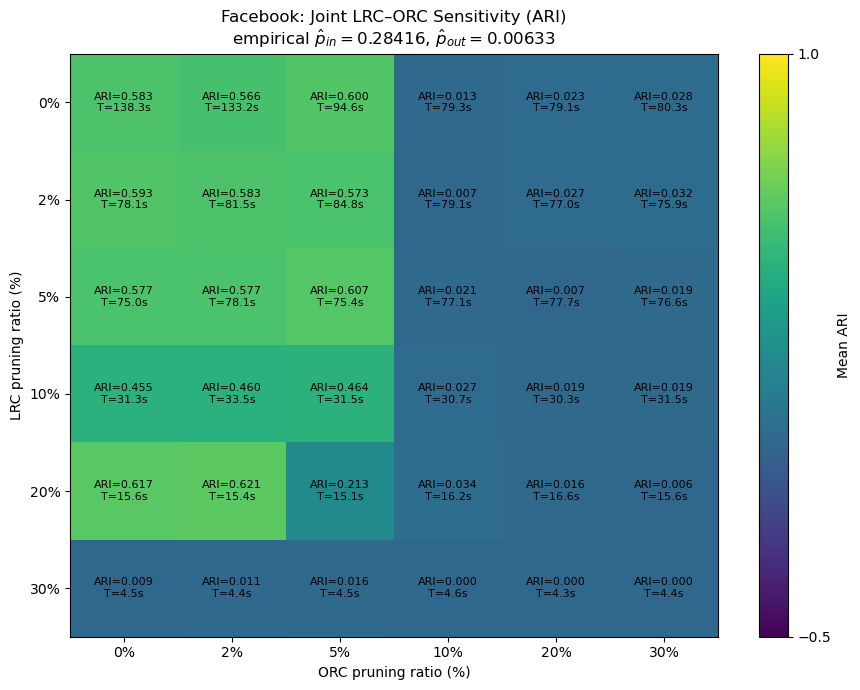

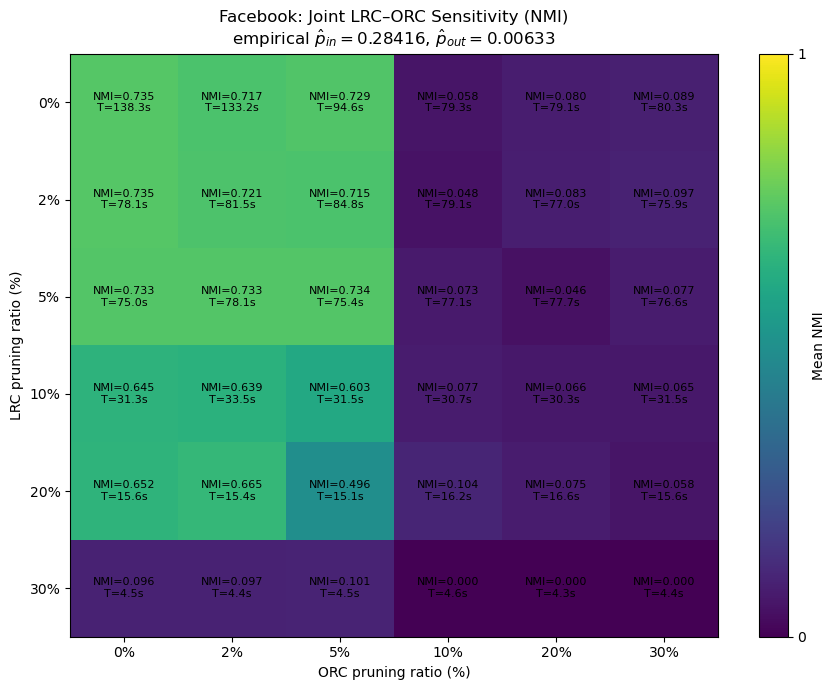


Saved:
  facebook_ari_lrc_orc_heatmap_with_runtime.png
  facebook_nmi_lrc_orc_heatmap_with_runtime.png
  facebook_lrc_orc_heatmap_summary.csv
  facebook_lrc_orc_heatmap_raw.csv
  facebook_empirical_pin_pout.csv


In [19]:
# ============================================================
# FACEBOOK: JOINT LRC-ORC PRUNING HEATMAPS
# Each cell shows accuracy + runtime
# p_in and p_out are estimated from the actual Facebook benchmark
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 0. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = Path(
    "./facebook_heatmaps"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 1. ESTIMATE EMPIRICAL p_in AND p_out
# ============================================================

def estimate_empirical_pin_pout(
    graph,
    label_attribute="label_gt",
):

    # --------------------------------------------------------
    # Keep nodes with an evaluation label
    # --------------------------------------------------------

    labeled_nodes = [
        node
        for node in graph.nodes()
        if label_attribute
        in graph.nodes[node]
    ]


    labels = {
        node:
            graph.nodes[node][
                label_attribute
            ]
        for node in labeled_nodes
    }


    # --------------------------------------------------------
    # Number of nodes in each ground-truth community
    # --------------------------------------------------------

    label_counts = (
        pd.Series(
            list(
                labels.values()
            )
        )
        .value_counts()
        .to_dict()
    )


    # --------------------------------------------------------
    # Possible within-community node pairs
    # --------------------------------------------------------

    possible_within = sum(
        n * (n - 1) / 2
        for n in label_counts.values()
    )


    total_nodes = len(
        labeled_nodes
    )


    possible_total = (
        total_nodes
        * (total_nodes - 1)
        / 2
    )


    possible_between = (
        possible_total
        - possible_within
    )


    # --------------------------------------------------------
    # Count observed within/between edges
    # --------------------------------------------------------

    observed_within = 0
    observed_between = 0


    labeled_set = set(
        labeled_nodes
    )


    for u, v in graph.edges():

        if (
            u not in labeled_set
            or v not in labeled_set
        ):
            continue


        if labels[u] == labels[v]:

            observed_within += 1

        else:

            observed_between += 1


    # --------------------------------------------------------
    # Empirical probabilities
    # --------------------------------------------------------

    p_in_hat = (
        observed_within
        / possible_within
        if possible_within > 0
        else np.nan
    )


    p_out_hat = (
        observed_between
        / possible_between
        if possible_between > 0
        else np.nan
    )


    return {

        "p_in":
            p_in_hat,

        "p_out":
            p_out_hat,

        "observed_within_edges":
            observed_within,

        "observed_between_edges":
            observed_between,

        "possible_within_pairs":
            possible_within,

        "possible_between_pairs":
            possible_between,

        "n_labeled":
            total_nodes,

        "n_labels":
            len(
                label_counts
            ),
    }


facebook_structure = (
    estimate_empirical_pin_pout(
        H,
        label_attribute="label_gt",
    )
)


FACEBOOK_PIN = (
    facebook_structure[
        "p_in"
    ]
)

FACEBOOK_POUT = (
    facebook_structure[
        "p_out"
    ]
)


print(
    "=" * 70
)

print(
    "FACEBOOK EMPIRICAL STRUCTURE"
)

print(
    "=" * 70
)


print(
    f"Nodes       : "
    f"{facebook_structure['n_labeled']}"
)

print(
    f"Labels      : "
    f"{facebook_structure['n_labels']}"
)

print(
    f"Within edges: "
    f"{facebook_structure['observed_within_edges']}"
)

print(
    f"Between edges: "
    f"{facebook_structure['observed_between_edges']}"
)

print(
    f"Estimated p_in  = "
    f"{FACEBOOK_PIN:.6f}"
)

print(
    f"Estimated p_out = "
    f"{FACEBOOK_POUT:.6f}"
)


# ============================================================
# 2. SENSITIVITY GRID
# ============================================================

# Includes the current 2% / 2% Facebook setting
LRC_HEAT_VALUES = [
    0,
    2,
    5,
    10,
    20,
    30,
]


ORC_HEAT_VALUES = [
    0,
    2,
    5,
    10,
    20,
    30,
]


HEATMAP_ALPHA = 0.5


HEATMAP_SEEDS = [
    0,
    1,
    2,
    3,
    4,
    42,
]


print(
    "\n"
    + "=" * 70
)

print(
    "FACEBOOK JOINT LRC-ORC SENSITIVITY"
)

print(
    "=" * 70
)

print(
    "LRC values:",
    LRC_HEAT_VALUES,
)

print(
    "ORC values:",
    ORC_HEAT_VALUES,
)

print(
    "alpha:",
    HEATMAP_ALPHA,
)

print(
    "seeds:",
    HEATMAP_SEEDS,
)


# ============================================================
# 3. RUN ALL PRUNING CONFIGURATIONS
# ============================================================

heatmap_rows = []


for lrc_pct in LRC_HEAT_VALUES:

    for orc_pct in ORC_HEAT_VALUES:

        print(
            f"\nRunning "
            f"LRC={lrc_pct}% | "
            f"ORC={orc_pct}% | "
            f"alpha={HEATMAP_ALPHA}"
        )


        # ----------------------------------------------------
        # Run curvature preprocessing once for this cell
        # ----------------------------------------------------

        try:

            combo_info_heat = (
                cdu.prepare_combo_graph(
                    graph=H,
                    lrc_pct=lrc_pct,
                    orc_pct=orc_pct,
                    alpha=HEATMAP_ALPHA,
                    iterations=ORC_ITERATIONS,
                    method="Sinkhorn",
                    weight="weight",
                )
            )


        except Exception as error:

            print(
                "Preparation failed:",
                repr(error),
            )


            for seed in HEATMAP_SEEDS:

                heatmap_rows.append(
                    {
                        "seed":
                            seed,

                        "lrc_pct":
                            lrc_pct,

                        "orc_pct":
                            orc_pct,

                        "alpha":
                            HEATMAP_ALPHA,

                        "p_in":
                            FACEBOOK_PIN,

                        "p_out":
                            FACEBOOK_POUT,

                        "ARI":
                            np.nan,

                        "NMI":
                            np.nan,

                        "Runtime":
                            np.nan,

                        "Prep_time":
                            np.nan,

                        "Community_time":
                            np.nan,

                        "V":
                            np.nan,

                        "E":
                            np.nan,

                        "status":
                            "failed",
                    }
                )

            continue


        # ----------------------------------------------------
        # Evaluate Louvain for different random seeds
        # ----------------------------------------------------

        for seed in HEATMAP_SEEDS:

            result = (
                cdu.evaluate_prepared_graph(
                    info=combo_info_heat,
                    algorithm="louvain",
                    seed=seed,
                    weight="weight",
                    label_attribute="label_gt",
                )
            )


            heatmap_rows.append(
                {
                    "seed":
                        seed,

                    "lrc_pct":
                        lrc_pct,

                    "orc_pct":
                        orc_pct,

                    "alpha":
                        HEATMAP_ALPHA,

                    "p_in":
                        FACEBOOK_PIN,

                    "p_out":
                        FACEBOOK_POUT,

                    "ARI":
                        result[
                            "ARI"
                        ],

                    "NMI":
                        result[
                            "NMI"
                        ],

                    "Runtime":
                        result[
                            "runtime_sec"
                        ],

                    "Prep_time":
                        result[
                            "prep_time"
                        ],

                    "Community_time":
                        result[
                            "community_time"
                        ],

                    "V":
                        result[
                            "V"
                        ],

                    "E":
                        result[
                            "E"
                        ],

                    "status":
                        "ok",
                }
            )


df_facebook_heatmap_raw = (
    pd.DataFrame(
        heatmap_rows
    )
)


# ============================================================
# 4. MEAN ± STD ACROSS SEEDS
# ============================================================

df_facebook_heatmap_valid = (
    df_facebook_heatmap_raw[
        df_facebook_heatmap_raw[
            "status"
        ] == "ok"
    ]
    .copy()
)


facebook_heatmap_summary = (
    df_facebook_heatmap_valid
    .groupby(
        [
            "lrc_pct",
            "orc_pct",
        ],
        as_index=False,
    )
    .agg(

        ARI_mean=(
            "ARI",
            "mean",
        ),

        ARI_std=(
            "ARI",
            "std",
        ),

        NMI_mean=(
            "NMI",
            "mean",
        ),

        NMI_std=(
            "NMI",
            "std",
        ),

        Runtime_mean=(
            "Runtime",
            "mean",
        ),

        Runtime_std=(
            "Runtime",
            "std",
        ),

        Prep_time_mean=(
            "Prep_time",
            "mean",
        ),

        Community_time_mean=(
            "Community_time",
            "mean",
        ),

        V_mean=(
            "V",
            "mean",
        ),

        E_mean=(
            "E",
            "mean",
        ),
    )
)


print(
    "\nFacebook joint sensitivity summary:"
)

display(
    facebook_heatmap_summary
)


# ============================================================
# 5. CONVERT SUMMARY TO HEATMAP MATRICES
# ============================================================

def make_heatmap_matrix(
    dataframe,
    value_column,
):

    return (
        dataframe
        .pivot(
            index="lrc_pct",
            columns="orc_pct",
            values=value_column,
        )
        .reindex(
            index=LRC_HEAT_VALUES,
            columns=ORC_HEAT_VALUES,
        )
    )


ari_matrix = (
    make_heatmap_matrix(
        facebook_heatmap_summary,
        "ARI_mean",
    )
)


nmi_matrix = (
    make_heatmap_matrix(
        facebook_heatmap_summary,
        "NMI_mean",
    )
)


runtime_matrix = (
    make_heatmap_matrix(
        facebook_heatmap_summary,
        "Runtime_mean",
    )
)


# ============================================================
# 6. HEATMAP PLOTTING FUNCTION
#
# COLOR = accuracy
# TEXT  = accuracy + runtime
# ============================================================

def plot_facebook_metric_heatmap(
    metric_matrix,
    runtime_matrix,
    metric_name,
):

    fig, ax = plt.subplots(
        figsize=(9, 7)
    )


    # --------------------------------------------------------
    # Metric-specific color scale
    # ARI: -0.5 to 1
    # NMI:  0 to 1
    # --------------------------------------------------------

    if metric_name == "ARI":

        vmin = -0.5
        vmax = 1.0

        colorbar_ticks = [
            -0.5,
            1.0,
        ]

    elif metric_name == "NMI":

        vmin = 0.0
        vmax = 1.0

        colorbar_ticks = [
            0.0,
            1.0,
        ]

    else:

        vmin = None
        vmax = None
        colorbar_ticks = None


    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    im = ax.imshow(
        metric_matrix.values,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )


    # --------------------------------------------------------
    # ORC pruning on horizontal axis
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(
                ORC_HEAT_VALUES
            )
        )
    )


    ax.set_xticklabels(
        [
            f"{value}%"
            for value
            in ORC_HEAT_VALUES
        ]
    )


    # --------------------------------------------------------
    # LRC pruning on vertical axis
    # --------------------------------------------------------

    ax.set_yticks(
        np.arange(
            len(
                LRC_HEAT_VALUES
            )
        )
    )


    ax.set_yticklabels(
        [
            f"{value}%"
            for value
            in LRC_HEAT_VALUES
        ]
    )


    ax.set_xlabel(
        "ORC pruning ratio (%)"
    )


    ax.set_ylabel(
        "LRC pruning ratio (%)"
    )


    ax.set_title(
        f"Facebook: Joint LRC–ORC Sensitivity ({metric_name})\n"
        f"empirical "
        f"$\\hat{{p}}_{{in}}={FACEBOOK_PIN:.5f}$, "
        f"$\\hat{{p}}_{{out}}={FACEBOOK_POUT:.5f}$"
    )


    # --------------------------------------------------------
    # Cell annotations
    # --------------------------------------------------------

    for i, lrc_pct in enumerate(
        LRC_HEAT_VALUES
    ):

        for j, orc_pct in enumerate(
            ORC_HEAT_VALUES
        ):


            metric_value = (
                metric_matrix.loc[
                    lrc_pct,
                    orc_pct
                ]
            )


            runtime_value = (
                runtime_matrix.loc[
                    lrc_pct,
                    orc_pct
                ]
            )


            if (
                pd.isna(
                    metric_value
                )
                or pd.isna(
                    runtime_value
                )
            ):

                text = "failed"


            else:

                text = (
                    f"{metric_name}="
                    f"{metric_value:.3f}\n"
                    f"T="
                    f"{runtime_value:.1f}s"
                )


            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8,
            )


    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax,
    )


    if colorbar_ticks is not None:

        cbar.set_ticks(
            colorbar_ticks
        )


    cbar.set_label(
        f"Mean {metric_name}"
    )


    fig.tight_layout()

    return fig


# ============================================================
# 7. ARI HEATMAP
# ============================================================

fig_ari = (
    plot_facebook_metric_heatmap(
        metric_matrix=
            ari_matrix,

        runtime_matrix=
            runtime_matrix,

        metric_name=
            "ARI",
    )
)


plt.show()


# ============================================================
# 8. NMI HEATMAP
# ============================================================

fig_nmi = (
    plot_facebook_metric_heatmap(
        metric_matrix=
            nmi_matrix,

        runtime_matrix=
            runtime_matrix,

        metric_name=
            "NMI",
    )
)


plt.show()


# ============================================================
# 9. SAVE FIGURES AND CSV FILES
# ============================================================

fig_ari.savefig(
    OUTPUT_DIR
    / "facebook_ari_lrc_orc_heatmap_with_runtime.png",
    dpi=300,
    bbox_inches="tight",
)


fig_nmi.savefig(
    OUTPUT_DIR
    / "facebook_nmi_lrc_orc_heatmap_with_runtime.png",
    dpi=300,
    bbox_inches="tight",
)


facebook_heatmap_summary.to_csv(
    OUTPUT_DIR
    / "facebook_lrc_orc_heatmap_summary.csv",
    index=False,
)


df_facebook_heatmap_raw.to_csv(
    OUTPUT_DIR
    / "facebook_lrc_orc_heatmap_raw.csv",
    index=False,
)


pd.DataFrame(
    [facebook_structure]
).to_csv(
    OUTPUT_DIR
    / "facebook_empirical_pin_pout.csv",
    index=False,
)


plt.close(
    fig_ari
)

plt.close(
    fig_nmi
)


print(
    "\nSaved:"
)

print(
    "  facebook_ari_lrc_orc_heatmap_with_runtime.png"
)

print(
    "  facebook_nmi_lrc_orc_heatmap_with_runtime.png"
)

print(
    "  facebook_lrc_orc_heatmap_summary.csv"
)

print(
    "  facebook_lrc_orc_heatmap_raw.csv"
)

print(
    "  facebook_empirical_pin_pout.csv"
)


Facebook
empirical p_in  = 0.284161
empirical p_out = 0.006329

Facebook | LRC=0% | ORC=0%
seed=0 | ARI=0.584 | NMI=0.736 | T=127.82s
seed=1 | ARI=0.584 | NMI=0.736 | T=127.78s

Facebook | LRC=0% | ORC=5%
seed=0 | ARI=0.601 | NMI=0.730 | T=124.60s
seed=1 | ARI=0.600 | NMI=0.730 | T=124.52s

Facebook | LRC=0% | ORC=10%
seed=0 | ARI=0.011 | NMI=0.047 | T=95.79s
seed=1 | ARI=0.027 | NMI=0.094 | T=95.77s

Facebook | LRC=0% | ORC=20%
seed=0 | ARI=0.025 | NMI=0.089 | T=75.18s
seed=1 | ARI=-0.005 | NMI=0.029 | T=75.19s

Facebook | LRC=0% | ORC=30%
seed=0 | ARI=0.027 | NMI=0.087 | T=76.27s
seed=1 | ARI=0.038 | NMI=0.109 | T=76.27s

Facebook | LRC=5% | ORC=0%
seed=0 | ARI=0.577 | NMI=0.732 | T=73.92s
seed=1 | ARI=0.577 | NMI=0.733 | T=73.90s

Facebook | LRC=5% | ORC=5%
seed=0 | ARI=0.588 | NMI=0.730 | T=73.18s
seed=1 | ARI=0.587 | NMI=0.729 | T=73.05s

Facebook | LRC=5% | ORC=10%
seed=0 | ARI=0.029 | NMI=0.094 | T=78.16s
seed=1 | ARI=0.012 | NMI=0.049 | T=78.15s

Facebook | LRC=5% | ORC=20%
se

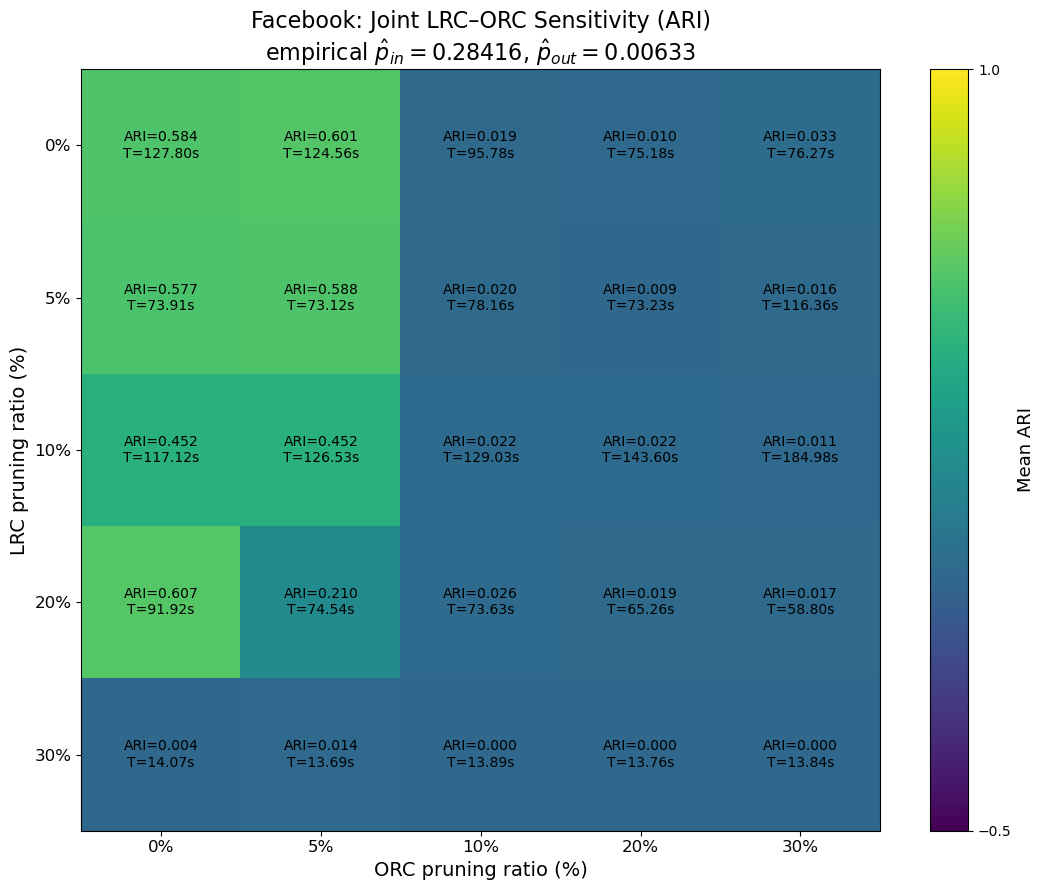

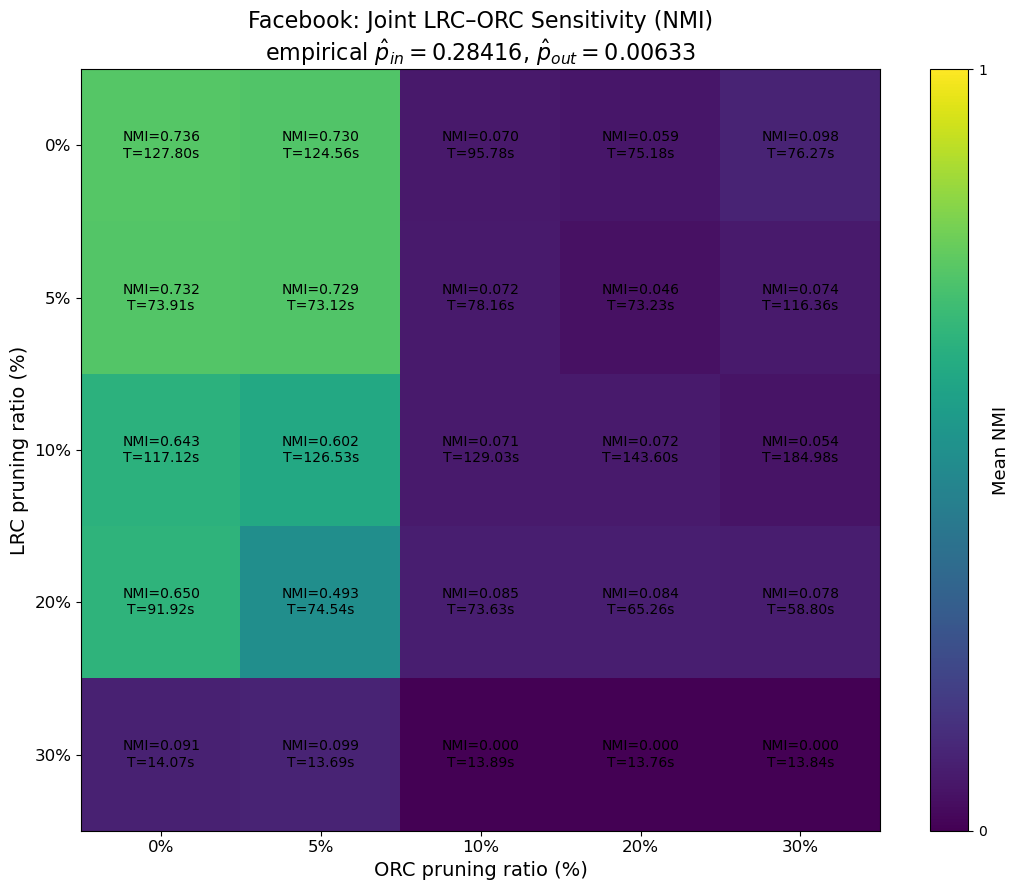

In [25]:
facebook_raw, facebook_summary = cdu.run_real_dataset_heatmap(
    H,
    "Facebook",
    orc_iterations=5
)